In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
from tifffile import tifffile
from skimage.color import rgb2gray
from skimage.transform import resize
import matplotlib.pyplot as plt
import numpy as np
import scipy
import sys
import os
sys.path.append('../fibermetric')
import sta_validate

# Load 3D Image

In [10]:
HOME = '/Users/brysongray/git_repos/fibermetric/example_image_analysis'
fname = 'two_angle_roi_2d_1.tif'
# path = '/home/brysongray/data/amg_data/two_angle_patch_3.tif'
img = tifffile.imread(os.path.join(HOME, fname))

In [11]:
img.shape

(100, 100)

## Choose Regions to Crop

In [5]:
print(img.shape)
print(img.dtype)
print(img.max())
print(img.min())

single_angle_roi_1 = np.array([[71,2,1428], [96,185,1563]])
two_angle_roi_1 = np.array([[26,646,406], [55,750,522]])
two_angle_roi_2 = np.array([[103,279,2589], [89,349,2687]])
two_angle_roi_3 = np.array([[116, 263, 1500],
                            [152, 363, 1600]])

(497, 1028, 2828)
uint8
255
0


## Crop and Upsample

In [59]:
I = img[two_angle_roi_2[1,0]:two_angle_roi_2[0,0], two_angle_roi_2[0,1]:two_angle_roi_2[1,1], two_angle_roi_2[0,2]:two_angle_roi_2[1,2]]
I = I / 255

# upsample to isotropic by trilinear interpolatation
dI = (2.4092, 0.8658, 0.8658)
x = [np.arange(n)*d for n,d in zip(I.shape, dI)]
# x = [np.arange(n) for n in I.shape]
Xout = np.stack(np.meshgrid(*[np.arange(n).astype(float) for n in [np.round(I.shape[0]*dI[0]/dI[1]), I.shape[1]*dI[1], I.shape[2]*dI[2]]],\
                             indexing='ij'), axis=-1)
I = scipy.interpolate.interpn(points=x, values=I, xi=Xout, method='linear', bounds_error=False, fill_value=0.0)
I = I[:32, :60]

In [62]:
I = img[two_angle_roi_1[0,0]:two_angle_roi_1[1,0], two_angle_roi_1[0,1]:two_angle_roi_1[1,1], two_angle_roi_1[0,2]:two_angle_roi_1[1,2]]
I = I / 255

# upsample to isotropic by trilinear interpolatation
dI = (2.4092, 0.8658, 0.8658)
x = [np.arange(n)*d for n,d in zip(I.shape, dI)]
# x = [np.arange(n) for n in I.shape]
Xout = np.stack(np.meshgrid(*[np.arange(n).astype(float) for n in [np.round(I.shape[0]*dI[0]/dI[1]), I.shape[1]*dI[1], I.shape[2]*dI[2]]],\
                             indexing='ij'), axis=-1)
I = scipy.interpolate.interpn(points=x, values=I, xi=Xout, method='linear', bounds_error=False, fill_value=0.0)
I = I[:68, :90]

In [65]:
I = img[single_angle_roi[0,0]:single_angle_roi[1,0], single_angle_roi[0,1]:single_angle_roi[1,1], single_angle_roi[0,2]:single_angle_roi[1,2]]
I = I / 255

# upsample to isotropic by trilinear interpolatation
dI = (2.4092, 0.8658, 0.8658)
x = [np.arange(n)*d for n,d in zip(I.shape, dI)]
# x = [np.arange(n) for n in I.shape]
Xout = np.stack(np.meshgrid(*[np.arange(n).astype(float) for n in [np.round(I.shape[0]*dI[0]/dI[1]), I.shape[1]*dI[1], I.shape[2]*dI[2]]],\
                             indexing='ij'), axis=-1)
I = scipy.interpolate.interpn(points=x, values=I, xi=Xout, method='linear', bounds_error=False, fill_value=0.0)
I = I[:58,:158]

In [6]:
z0 = 116
z1 = 152
y0 = 263
y1 = 363
x0 = 1500
x1 = 1600
two_angle_roi_3 = np.array([[z0, y0, x0],
                            [z1, y1, x1]])
I = img[two_angle_roi_3[0,0]:two_angle_roi_3[1,0], two_angle_roi_3[0,1]:two_angle_roi_3[1,1], two_angle_roi_3[0,2]:two_angle_roi_3[1,2]]
I = I / 255

# upsample to isotropic by trilinear interpolatation
dI = (2.4092, 0.8658, 0.8658)
x = [np.arange(n)*d for n,d in zip(I.shape, dI)]
# x = [np.arange(n) for n in I.shape]
Xout = np.stack(np.meshgrid(*[np.arange(0,n*d, step=dI[1]) for n, d in zip(I.shape, dI)],\
                             indexing='ij'), axis=-1)
I = scipy.interpolate.interpn(points=x, values=I, xi=Xout, method='linear', bounds_error=False, fill_value=0.0)
print(I.shape)
I = I[:-1]
print(I.shape)

(101, 100, 100)
(100, 100, 100)


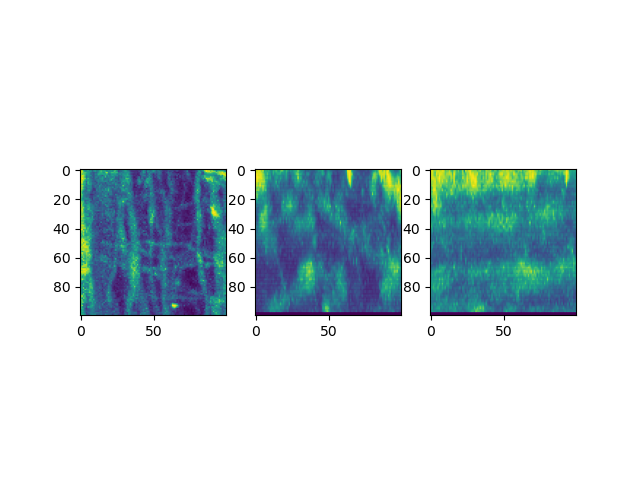

In [7]:
# nrows = 5
plt.close('all')
fig, ax = plt.subplots(1,3)

# z = I.shape[0]//2
# y = I.shape[1]//2
# x = I.shape[2]//2
# ax[0].imshow(I[z])
# ax[1].imshow(I[:,y])
# ax[2].imshow(I[:,:,x])
ax[0].imshow(I.max(axis=0))
ax[1].imshow(I.max(axis=1))
ax[2].imshow(I.max(axis=2))

In [8]:
I = I * 255
I = I.astype(np.uint8)
tifffile.imwrite('/home/brysongray/fibermetric/example_image_analysis/two_angle_roi_3d_3.tif', I)

## Downsample 3D patch

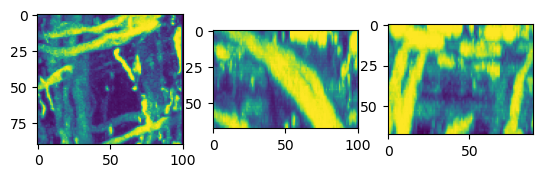

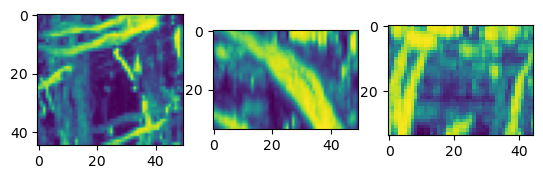

In [13]:
HOME = '/Users/brysongray/git_repos/fibermetric'
I = tifffile.imread(os.path.join(HOME, "example_image_analysis/two_angle_roi_3d_1.tif"))
down = 2
image_resized = resize(
    I, (I.shape[0] // down, I.shape[1] // down, I.shape[2] // down), anti_aliasing=True
)

fig, ax = plt.subplots(1,3)

ax[0].imshow(I.max(axis=0))
ax[1].imshow(I.max(axis=1))
ax[2].imshow(I.max(axis=2))

fig, ax = plt.subplots(1,3)
ax[0].imshow(image_resized.max(axis=0))
ax[1].imshow(image_resized.max(axis=1))
ax[2].imshow(image_resized.max(axis=2))

tifffile.imwrite(os.path.join(HOME, "example_image_analysis/two_angle_roi_3d_1_down_2.tif"), image_resized)

# Load 2D Image

In [73]:
path = "/home/brysongray/data/hongwei_data/SF221013_02A/bk/SF221013_02A_BK_JIANDONG_AD_04_12_20x_BF_12_down4.tif"
# path = "/home/brysongray/data/hongwei_data/SF221013_02A/bk/SF221013_02A_BK_JIANDONG_AD_04_05_20x_BF_05_down4.tif"
img = tifffile.imread(path)

In [74]:
img_gray = rgb2gray(img)
print(img_gray.shape)
print(img_gray.dtype)
print(img_gray.max())
print(img_gray.min())

single_angle_roi = np.array([[2700,2900],
                             [2800,3000]])
two_angle_roi_1 = np.array([[3930,4730], [4030,4830]])
# two_angle_roi_2 = np.array([[103,279,2589],[89,349,2687]])

(5582, 6711)
float64
0.9994345098039217
0.0


In [78]:
I = img_gray[single_angle_roi[0,0]:single_angle_roi[1,0], single_angle_roi[0,1]:single_angle_roi[1,1]]
I = 1.0 - I

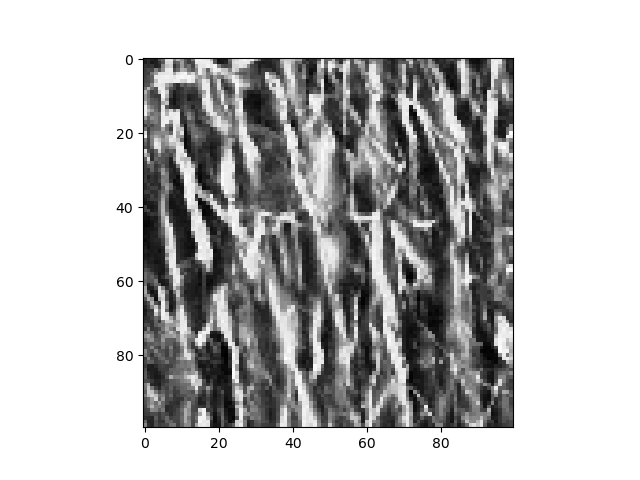

In [79]:
fig = plt.figure()
plt.imshow(I, cmap='gray')

In [80]:
tifffile.imwrite('/home/brysongray/fibermetric/example_image_analysis/single_angle_roi_2d_1.tif', I)

In [86]:
path = "/home/brysongray/data/hongwei_data/SF221013_02A/bk/SF221013_02A_BK_JIANDONG_AD_03_05_20x_BF_05_down4.tif"
img = tifffile.imread(path)
img_gray = rgb2gray(img)


In [87]:
I = img_gray[two_angle_roi_1[0,0]:two_angle_roi_1[1,0], two_angle_roi_1[0,1]:two_angle_roi_1[1,1]]
I = 1.0 - I

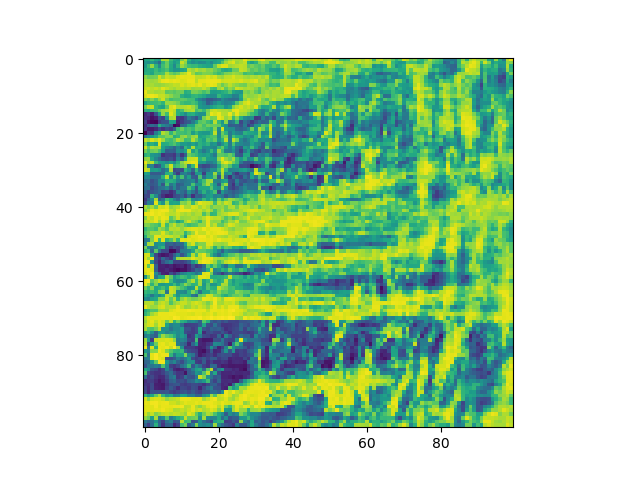

In [88]:
fig = plt.figure()
plt.imshow(I)

In [89]:
tifffile.imwrite('/home/brysongray/fibermetric/example_image_analysis/two_angle_roi_2d_1.tif', I)